In [2]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.4 MB 12.7 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.4 MB 12.0 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.4 MB 12.7 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 10.9 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   --- ------------------------------------ 2.9/37.4 MB 13.7 MB/s eta 0:00:03
   ------ --------------------------------- 5.8/37.4 MB 14.0 MB/s eta 0:00:03
   --------- ------------------------------ 8.9/37.4 MB 14.0 MB/s eta 0:00:03
   ------------ --------------------------- 11.8/37.4 MB 14.0 MB/s eta 0:00:02
   --------------- ------------------------ 14.9/37.4 MB 14.2 MB/s eta 0:00:02
   ------------------- -------------------- 17.8/37.4 MB 14.4 MB/s eta 0:00:02
   ---------------------- ----------------- 21.0/37.4 MB 14.4 MB/s eta 0:00:02
   ---

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("task dataset.csv")

# Clean dataset
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,05-11-2022,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,09-07-2022,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,12-12-2022,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,06-01-2022,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,14-11-2022,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


In [9]:
# Convert sale_date using format='%d-%m-%Y'
df['sale_date'] = pd.to_datetime(
    df['sale_date'], format='%d-%m-%Y', errors='coerce'
)

# Reference date for recency calculation
max_date = df['sale_date'].max()

# Calculate Recency, Frequency, and Monetary (RFM) values
rfm = (
    df.groupby('customer_id')
    .agg({
        'sale_date': lambda x: (max_date - x.max()).days,  # Recency
        'transactions_id': 'count',  # Frequency
        'total_sale': 'sum',  # Monetary
    })
    .reset_index()
)

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,1,20,76,30750.0
1,2,24,69,25295.0
2,3,0,76,38440.0
3,4,1,73,23580.0
4,5,1,63,30405.0


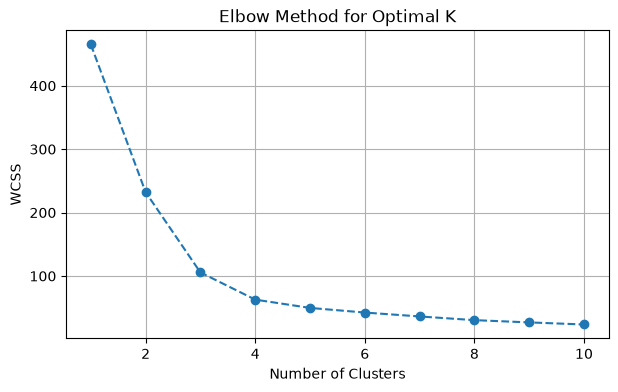

,customer_id,Recency,Frequency,Monetary,Cluster
0,1,20,76,30750.0,2
1,2,24,69,25295.0,2
2,3,0,76,38440.0,2
3,4,1,73,23580.0,2
4,5,1,63,30405.0,2


In [10]:
# Scale RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Elbow Method to find optimal K
wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(rfm_scaled)
  wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Apply K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

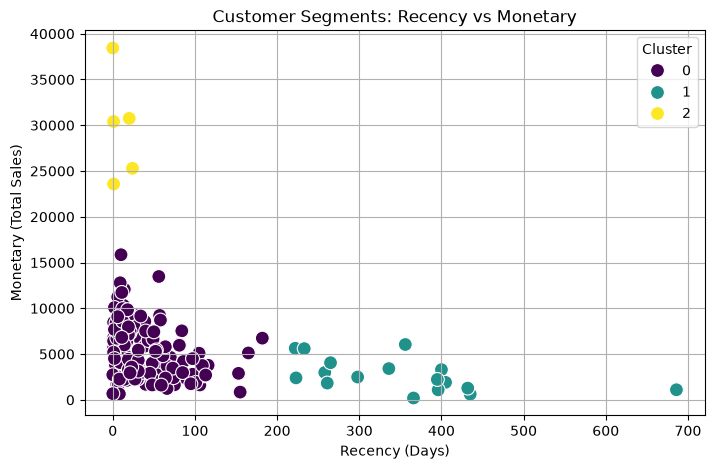

            Recency  Frequency      Monetary  customer_id
Cluster                                                  
0         41.894737  11.511278   5365.300752          133
1        351.000000   5.823529   2716.176471           17
2          9.200000  71.400000  29694.000000            5


In [11]:
# Plot customer clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=100,
)
plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary (Total Sales)')
plt.grid(True)
plt.show()

# Summary statistics per cluster
cluster_summary = rfm.groupby('Cluster').agg(
    {
        'Recency': 'mean',
        'Frequency': 'mean',
        'Monetary': 'mean',
        'customer_id': 'count',
    }
)
print(cluster_summary)

## Task 2 - Customer Segmentation Insights & Recommendations

### Cluster Profiles
1. **Cluster 0 (Moderate / Loyal Buyers)**: Low recency (\~41 days), moderate frequency (\~11 purchases), and steady spend (\~$5,365). They form the core active customer base.
2. **Cluster 1 (At-Risk / Inactive Customers)**: High recency (\~351 days), lower frequency (\~5 purchases), and low total spend (\~$2,716). These customers haven't purchased recently.
3. **Cluster 2 (VIP / High-Value Champions)**: Very low recency (\~9 days), extremely high frequency (\~71 purchases), and massive spend (\~$29,694). 

### Business Recommendations
* **VIP Champions (Cluster 2)**: Offer exclusive loyalty perks, early access to new product releases, and personalized VIP customer support to retain them.
* **At-Risk Customers (Cluster 1)**: Deploy win-back email campaigns with special discount incentives to re-engage them.
* **Loyal Core (Cluster 0)**: Implement multi-buy product bundles and cross-selling promotions to increase their basket value over time.